## Importing libraries

In [2]:
from sklearn.ensemble import RandomForestClassifier, VotingClassifier
from sklearn.metrics import accuracy_score
from sklearn.model_selection import GridSearchCV
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB
import os
import matplotlib.pyplot as plt
from skimage.feature import hog
import random
import cv2
import warnings


## Training and Testing Data

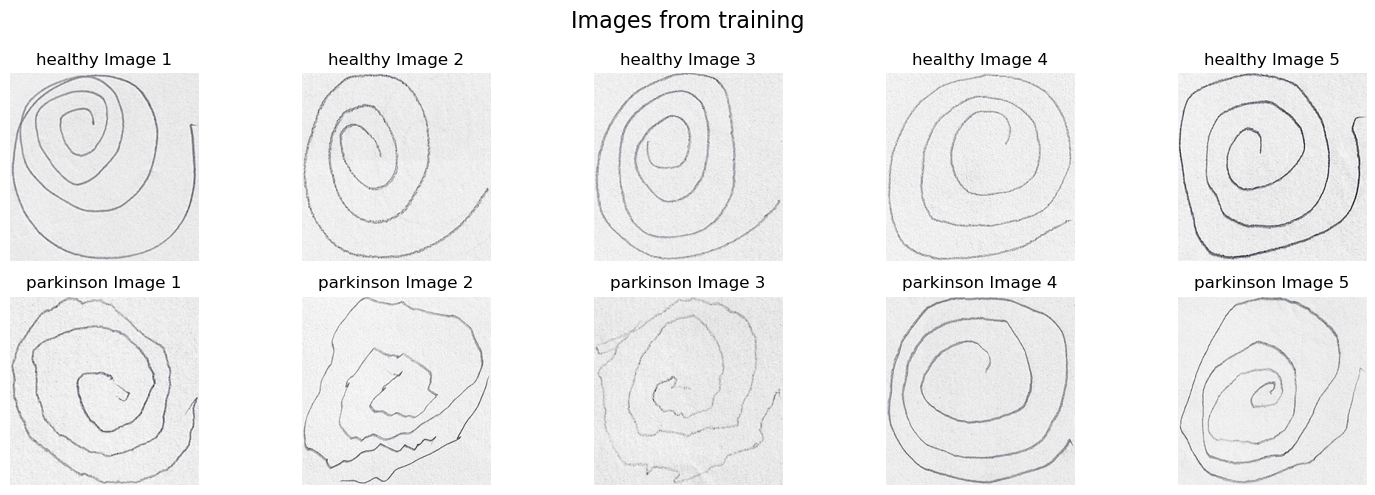

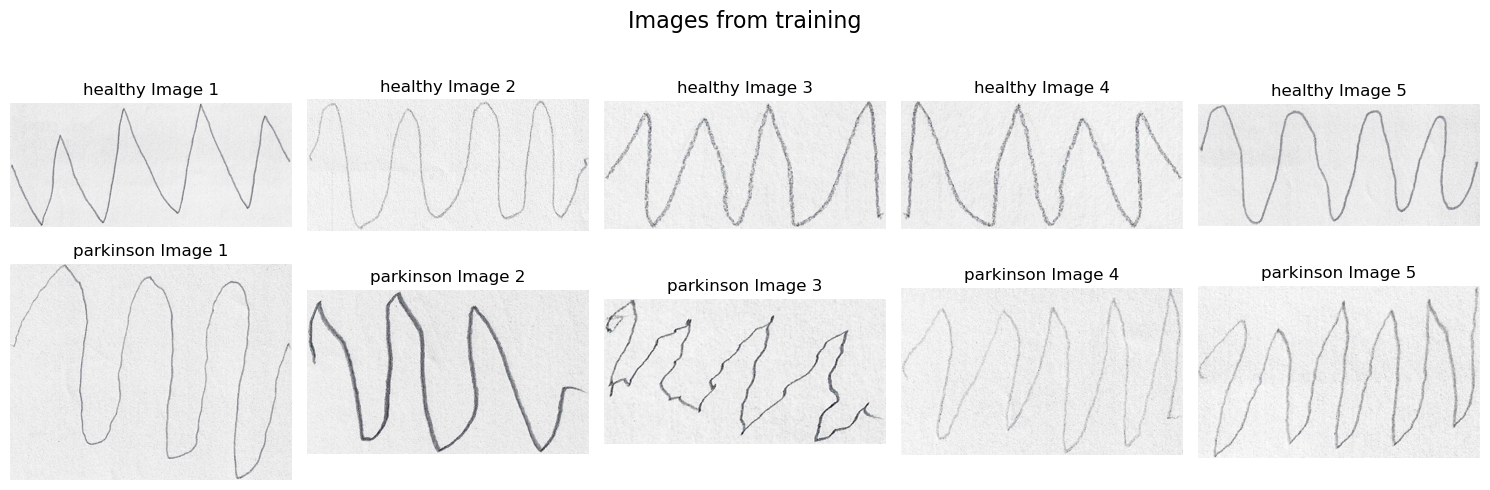

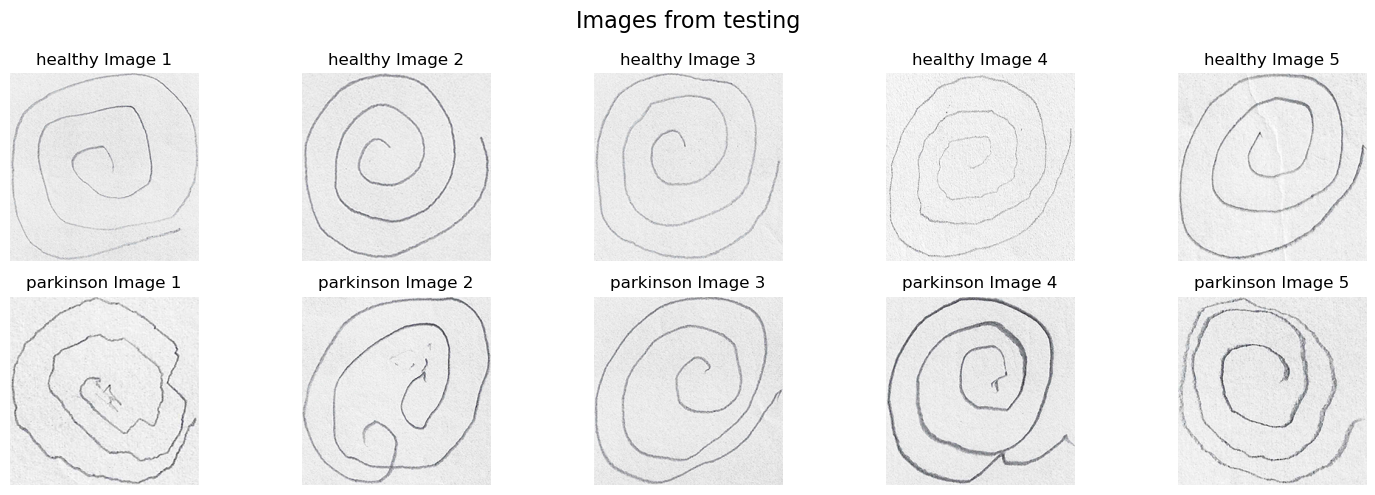

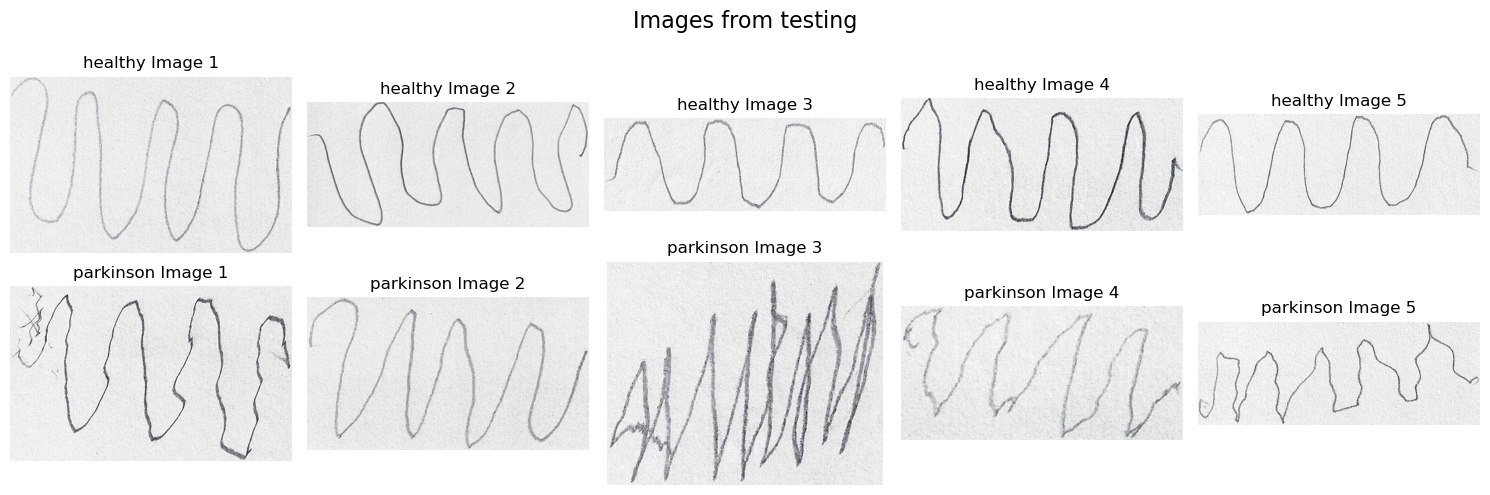

In [3]:

def display_images(directory, num_images=5):
    fig, axes = plt.subplots(2, num_images, figsize=(15, 5))
    fig.suptitle(f"Images from {directory.split('/')[-1]}", fontsize=16)
    
    for i, label in enumerate(os.listdir(directory)):
        label_dir = os.path.join(directory, label)
        image_files = os.listdir(label_dir)
        random.shuffle(image_files)
        for j in range(num_images):
            image_path = os.path.join(label_dir, image_files[j])
            img = cv2.imread(image_path)
            axes[i, j].imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
            axes[i, j].set_title(f"{label} Image {j+1}")
            axes[i, j].axis('off')
    plt.tight_layout()
    plt.show()


# Display training images
display_images("C://Users//91770//Downloads//drawings//drawings//spiral//training")
display_images("C://Users//91770//Downloads//drawings//drawings//wave//training")

# Display testing images
display_images("C://Users//91770//Downloads//drawings//drawings//spiral//testing")
display_images("C://Users//91770//Downloads//drawings//drawings//wave//testing")


##  Extracting Histogram of Oriented Gradients (HOG) features from an image

In [4]:
def extract_hog_features(image):
    hog_features = hog(image, orientations=9, pixels_per_cell=(8, 8), cells_per_block=(2, 2), visualize=False)
    return hog_features


## Load images from the given directory, resize them to 128x128 pixels, convert them to grayscale, and extract HOG (Histogram of Oriented Gradients) features from each image.

In [5]:
def load_and_extract_features(directory):
    X = []
    y = []
    for label in os.listdir(directory):
        label_dir = os.path.join(directory, label)
        for filename in os.listdir(label_dir):
            image_path = os.path.join(label_dir, filename)
            img = cv2.imread(image_path)
            img_resized = cv2.resize(img, (128, 128))
            img_gray = cv2.cvtColor(img_resized, cv2.COLOR_BGR2GRAY)
            hog_features = extract_hog_features(img_gray)
            X.append(hog_features)
            y.append(label)
    return X, y


## Train a Random Forest classifier with specified hyperparameters on the given training data.

In [6]:
def train_random_forest(X_train, y_train):
    rf_classifier = RandomForestClassifier(n_estimators=1000, criterion='gini', max_depth=5)
    rf_classifier.fit(X_train, y_train)
    return rf_classifier


## Train a Support Vector Machine(SVM) model with specified hyperparameters on the given training data.

In [7]:
def train_svm(X_train, y_train):
    svm_params = {'C': [0.1, 1, 10], 'kernel': ['linear', 'rbf']}
    svm_grid = GridSearchCV(SVC(), svm_params, cv=5, n_jobs=-1)
    svm_grid.fit(X_train, y_train)
    best_svm = svm_grid.best_estimator_
    return best_svm


## Train a Naive Bayes model with specified hyperparameters on the given training data.

In [8]:
def train_naive_bayes(X_train, y_train, alpha=1.0):
    nb_classifier = GaussianNB(var_smoothing=alpha)
    nb_classifier.fit(X_train, y_train)
    return nb_classifier


## Train a K-Nearest Neigbors (KNN) model with specified hyperparameters on the given training data.

In [9]:
def train_knn(X_train, y_train, n_neighbors=5, weights='uniform', algorithm='auto', leaf_size=30, p=2, metric='minkowski'):
    knn_classifier = KNeighborsClassifier(n_neighbors=n_neighbors, weights=weights, algorithm=algorithm, leaf_size=leaf_size, p=p, metric=metric)
    knn_classifier.fit(X_train, y_train)
    return knn_classifier


In [10]:
def train_models(X_train, y_train):
    models = []

    # Train Random Forest classifier
    rf_classifier = train_random_forest(X_train, y_train)
    models.append(('rf', rf_classifier))

    # Train SVM classifier
    svm_classifier = train_svm(X_train, y_train)
    models.append(('svm', svm_classifier))

    # Train Naive Bayes classifier
    nb_classifier = train_naive_bayes(X_train, y_train)
    models.append(('nb', nb_classifier))

    # Train KNN classifier
    knn_classifier = train_knn(X_train, y_train)
    models.append(('knn', knn_classifier))

    return models


## Evaluating the model 

In [11]:
def evaluate_classifier(classifier, X_test, y_test):
    predictions = classifier.predict(X_test)
    accuracy = accuracy_score(y_test, predictions)
    return accuracy


## Main function to execute the entire workflow: load data, perform hyperparameter tuning, train classifiers, evaluate performance, and train a Voting Classifier.


In [12]:
def main():
    # Load and extract features from training data
    spiral_train_X, spiral_train_y = load_and_extract_features("C://Users//91770//Downloads//drawings//drawings//spiral//training")
    wave_train_X, wave_train_y = load_and_extract_features("C://Users//91770//Downloads//drawings//drawings//wave//training")

    # Load and extract features from testing data
    spiral_test_X, spiral_test_y = load_and_extract_features("C://Users//91770//Downloads//drawings//drawings//spiral//testing")
    wave_test_X, wave_test_y = load_and_extract_features("C://Users//91770//Downloads//drawings//drawings//wave//testing")

    # Hyperparameter tuning for SVM classifier
    spiral_svm_classifier = train_svm(spiral_train_X, spiral_train_y)
    wave_svm_classifier = train_svm(wave_train_X, wave_train_y)

    # Hyperparameter tuning for Naive Bayes classifier
    best_accuracy = 0
    best_alpha = None

    for alpha in [0.1, 0.5, 1.0, 5.0, 10.0]:
        # Train Naive Bayes classifier with current alpha value
        spiral_nb_classifier = train_naive_bayes(spiral_train_X, spiral_train_y, alpha=alpha)
        wave_nb_classifier = train_naive_bayes(wave_train_X, wave_train_y, alpha=alpha)

        # Evaluate classifiers
        spiral_nb_accuracy = evaluate_classifier(spiral_nb_classifier, spiral_test_X, spiral_test_y)
        wave_nb_accuracy = evaluate_classifier(wave_nb_classifier, wave_test_X, wave_test_y)

        # Keep track of best alpha and accuracy
        if spiral_nb_accuracy + wave_nb_accuracy > best_accuracy:
            best_accuracy = spiral_nb_accuracy + wave_nb_accuracy
            best_alpha = alpha

    print("Best Alpha:", best_alpha)
    print("Spiral Naive Bayes Classification Accuracy:", spiral_nb_accuracy)
    print("Wave Naive Bayes Classification Accuracy:", wave_nb_accuracy)

    # Train Random Forest classifiers
    spiral_rf_classifier = train_random_forest(spiral_train_X, spiral_train_y)
    wave_rf_classifier = train_random_forest(wave_train_X, wave_train_y)

    # Make predictions using Random Forest classifiers
    spiral_rf_predictions = spiral_rf_classifier.predict(spiral_test_X)
    wave_rf_predictions = wave_rf_classifier.predict(wave_test_X)

    # Calculate accuracy scores for Random Forest classifiers
    spiral_rf_accuracy = accuracy_score(spiral_test_y, spiral_rf_predictions)
    wave_rf_accuracy = accuracy_score(wave_test_y, wave_rf_predictions)

    print("Spiral Random Forest Classification Accuracy:", spiral_rf_accuracy)
    print("Wave Random Forest Classification Accuracy:", wave_rf_accuracy)
    
    knn_classifier = train_knn(spiral_train_X, spiral_train_y)
    knn_accuracy = evaluate_classifier(knn_classifier, spiral_test_X, spiral_test_y)
    print("KNN Classifier Accuracy:", knn_accuracy)
    
    svm_classifier = train_svm(spiral_train_X, spiral_train_y)
    svm_accuracy = evaluate_classifier(svm_classifier, spiral_test_X, spiral_test_y)
    print("SVM Classifier Accuracy:", svm_accuracy)

    # Continue with the existing code...

    # Train models
    models = train_models(spiral_train_X, spiral_train_y)

    # Create Voting Classifier
    voting_classifier = VotingClassifier(estimators=models, voting='hard')
    voting_classifier.fit(spiral_train_X, spiral_train_y)

    # Evaluate Voting Classifier
    predictions = voting_classifier.predict(spiral_test_X)
    accuracy = accuracy_score(spiral_test_y, predictions)
    print("Voting Classifier Accuracy:", accuracy)


if __name__ == "__main__":
    warnings.filterwarnings("ignore", category=FutureWarning)
    main()


Best Alpha: 0.1
Spiral Naive Bayes Classification Accuracy: 0.7666666666666667
Wave Naive Bayes Classification Accuracy: 0.7
Spiral Random Forest Classification Accuracy: 0.7666666666666667
Wave Random Forest Classification Accuracy: 0.7
KNN Classifier Accuracy: 0.8333333333333334
SVM Classifier Accuracy: 0.7333333333333333
Voting Classifier Accuracy: 0.8
